## IPL data analysis

In [1]:
print("importing libraries...")
import pandas as pd
print("done!")

importing libraries...
done!


## Load CSV


In [2]:
matches = pd.read_csv("../Datasets/matches.csv")
deliveries = pd.read_csv("../Datasets/deliveries.csv")

## Top Batsman

In [5]:
matches

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,11347,IPL-2019,Mumbai,05-05-2019,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi
752,11412,IPL-2019,Chennai,07-05-2019,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,normal,0,Mumbai Indians,0,6,AS Yadav,M. A. Chidambaram Stadium,Nigel Llong,Nitin Menon,Ian Gould
753,11413,IPL-2019,Visakhapatnam,08-05-2019,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN
754,11414,IPL-2019,Visakhapatnam,10-05-2019,Delhi Capitals,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,6,F du Plessis,ACA-VDCA Stadium,Sundaram Ravi,Bruce Oxenford,Chettithody Shamshuddin


In [3]:
top_batsman = deliveries.groupby("batsman")["batsman_runs"].sum().sort_values(ascending=False).head(10)

print(top_batsman)

batsman
V Kohli           5434
SK Raina          5415
RG Sharma         4914
DA Warner         4741
S Dhawan          4632
CH Gayle          4560
MS Dhoni          4477
RV Uthappa        4446
AB de Villiers    4428
G Gambhir         4223
Name: batsman_runs, dtype: int64


## Top Bowlers

In [4]:
wickets = deliveries[deliveries["dismissal_kind"].notna()]

top_bowlers = wickets.groupby("bowler")["player_dismissed"].count() \
                    .sort_values(ascending=False).head(10)

print(top_bowlers)

bowler
SL Malinga         188
DJ Bravo           168
A Mishra           165
Harbhajan Singh    161
PP Chawla          156
B Kumar            141
R Ashwin           138
SP Narine          137
UT Yadav           136
R Vinay Kumar      127
Name: player_dismissed, dtype: int64


## Strike Rate

In [11]:
runs = deliveries.groupby("batsman")["batsman_runs"].sum()
balls = deliveries.groupby("batsman")["ball"].count()

strike_rate = (runs / balls) * 100
print(strike_rate.sort_values(ascending=False).head(10))

batsman
B Stanlake       250.000000
Umar Gul         205.263158
RS Sodhi         200.000000
S Sharma         200.000000
AD Russell       179.950187
Shahid Afridi    176.086957
I Malhotra       175.000000
S Curran         172.727273
K Gowtham        172.093023
SN Thakur        171.428571
dtype: float64


## Team Win Count

In [12]:
team_wins = matches["winner"].value_counts()
print(team_wins)

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Delhi Capitals                  10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64


## Toss Impact

In [13]:
toss_win_match_win = matches[matches["toss_winner"] == matches["winner"]]
percentage = len(toss_win_match_win) / len(matches) * 100

print(f"Toss win → Match win %: {percentage:.2f}%")

Toss win → Match win %: 51.98%


## Death Overs (16–20)

In [14]:
death_overs = deliveries[deliveries["over"] >= 16]

death_runs = death_overs.groupby("batsman")["batsman_runs"].sum() \
                        .sort_values(ascending=False).head(10)

print(death_runs)

batsman
MS Dhoni          2669
KA Pollard        1562
RG Sharma         1450
AB de Villiers    1412
V Kohli           1154
YK Pathan         1134
KD Karthik        1073
RA Jadeja          940
Yuvraj Singh       911
AT Rayudu          887
Name: batsman_runs, dtype: int64


## Visualization

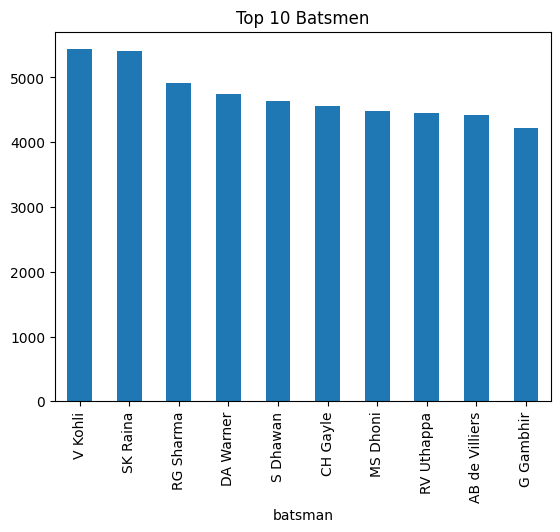

In [15]:
import matplotlib.pyplot as plt

top_batsman.plot(kind='bar')
plt.title("Top 10 Batsmen")
plt.show()

2026-04-15 07:58:22.961 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 07:58:22.983 
  command:

    streamlit run /Users/pankajsingh/.pyenv/versions/3.12.11/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-15 07:58:22.984 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-15 07:58:22.984 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


KeyError: 'batter'